# CIND 860 Project Technical Report - Demographic Risk Factors and Survival After Treatment in Acute Lymphoblastic Leukemia
# Francis Semenuk
# 500185004




##Abstract
This report presents a full data‑analytics workflow applied to a clinical acute lymphoblastic leukemia (ALL) dataset containing 1,510 patient records and 37 initial variables. The analysis includes data cleaning, missing‑value handling, categorical encoding, exploratory data analysis, correlation assessment, outlier evaluation, and multiple predictive modeling approaches: Random Forest, XGBoost, and a tuned Neural Network. The primary predictive target is vital_status, encoded as a three‑class outcome. Models were trained using SMOTE to address class imbalance and evaluated using accuracy, confusion matrices, ROC curves, and feature‑importance methods.

#1. Introduction
The dataset contains demographic, diagnostic, and treatment‑related variables for ALL cases. The goal of this project is to identify demographic and treatment factors associated with patient outcomes (1. Demographic risk factors, 2. Demographics vs. diagnostic typing, 3. Treatment type and 5-year survival).

The notebook begins by loading the dataset, performing extensive cleaning, removing unusable columns, and preparing the data for modeling. Subsequent steps include exploratory analysis, encoding, scaling, and training multiple machine‑learning models.

#2. Methodology
2.1 Data Loading

The dataset (clinical.tsv) is uploaded and read using pandas.read_csv with tab separation.

2.2 Initial Cleaning

A large number of columns contained only '--' values. These were converted to NaN and dropped.

After this step, the dataset was reduced to 37 columns.

2.3 Removing Low‑Information Columns

Two additional filtering steps were applied:

Columns with only one unique value were removed.

Columns with unique values per row (except cases.case_id) were removed.

2.4 Missing‑Value Analysis

A missing‑value percentage table was generated.

The column treatments.reason_treatment_ended required imputation. A subgroup‑based mode imputation was performed using male patients under age 5 residing in the United States.

2.5 Exploratory Data Analysis

EDA included:

Category distributions for all object‑type columns

Histogram of demographic.days_to_death  

Histogram of demographic.age_at_index  

Correlation heatmap after integer‑encoding categorical variables

Highly correlated pairs (|corr| ≥ 0.95) were identified and removed.

2.6 Outlier Detection

Outliers were identified using the IQR method across all numerical columns.

All outliers were deemed clinically plausible.

2.7 Encoding & Feature Engineering

Steps included:

One‑hot encoding of categorical variables

Binary encoding of gender, vital_status, and treatment_outcome

Standardization of selected numerical variables

Construction of demographic‑focused datasets (df_demographic, df_q1)

2.8 Modeling Approach

Three models were trained:

1. Random Forest

SMOTE applied to training data

Accuracy, confusion matrix, classification report generated

Feature importances extracted


2. XGBoost
Multi‑class softmax objective

Early stopping using test set

Feature importances extracted


3. Neural Network
SMOTE + StandardScaler

Custom Keras model builder

Manual hyperparameter tuning across: hidden layers, neurons, learning rate, activation, optimizer, batch size, epochs.

The best model was evaluated.

Permutation importance for class “Dead” identified

#3. Initial (incomplete) Results

3.1 Data Cleaning Results

Dozens of unusable columns removed (all '--' values).

Dataset reduced to meaningful clinical variables.

Missing values successfully imputed for treatment‑related fields.

3.2 Exploratory Analysis Results

Age distribution showed a wide range, including outliers that were clinically valid.

Correlation heatmap revealed several redundant variables, which were removed.

3.3 Model Performance for Prediction of vital_status based on demographics.

1. Random Forest

Achieved accuracy for predicting vital_status based on demographics of 0.5828. Overall a poor use of predicting vital_status in this case.

Top features included year_of_birth, age_at_index, race_white, gender, and ethnicity not hispanic or latino variables. This suggest the most influential demographic factors are age, being caucasian, gender influences, and not being hispanic or latino.


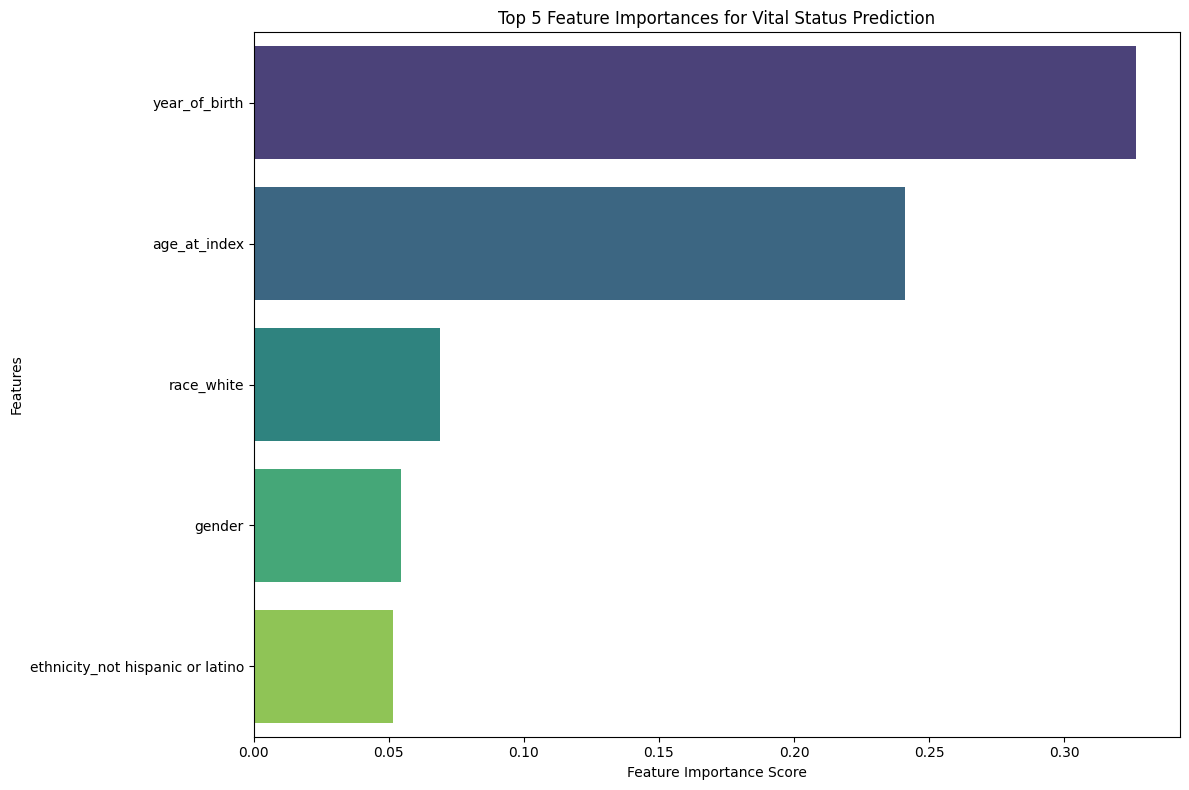
2. XGBoost

Early stopping improved generalization.

Achieved accuracy for predicting vital_status based on demographics of 0.5828. Overall a poor use of predicting vital_status in this case.

Feature importance highlighted different predictors compared to Random Forest, such as United States residence of enrollment, and Bahamas residence of enrollment. However a common predictor of race_white was among both.


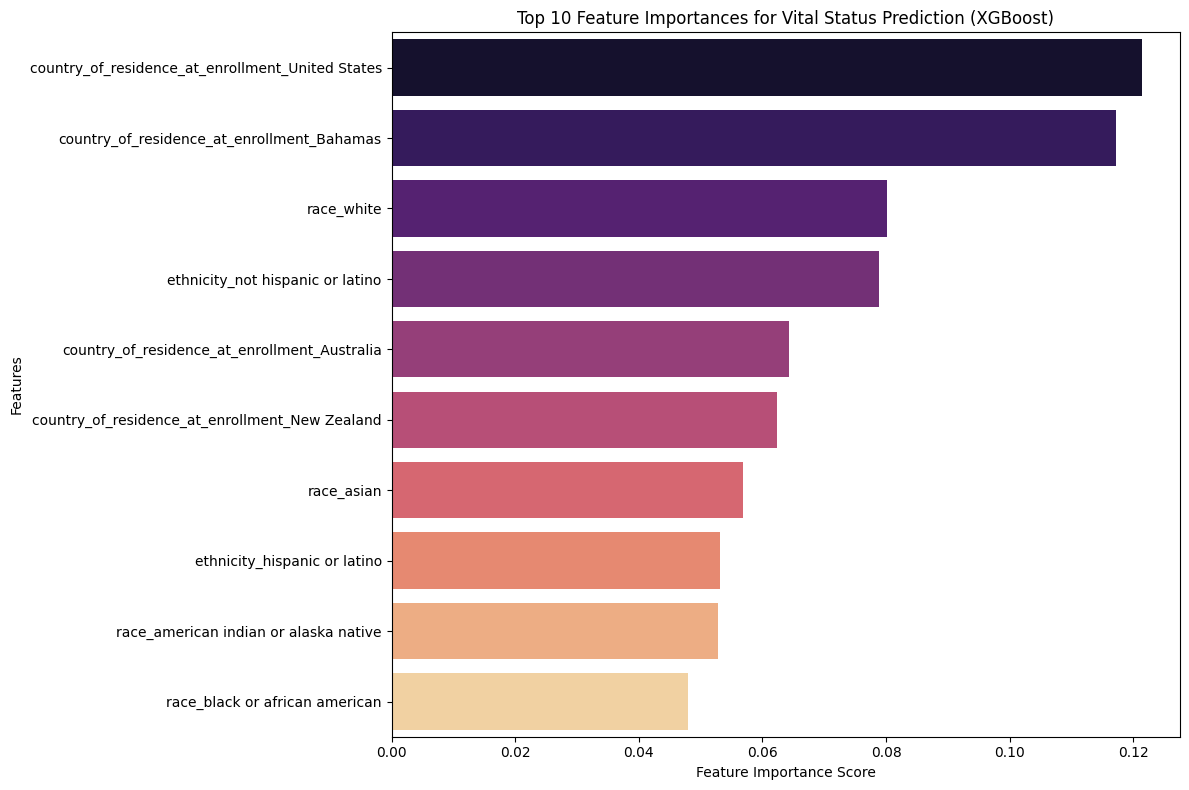
3. Neural Network

Manual tuning identified optimal hyperparameters.

Achieved strong performance after SMOTE + scaling.

Running against test dataset still needs to happen.
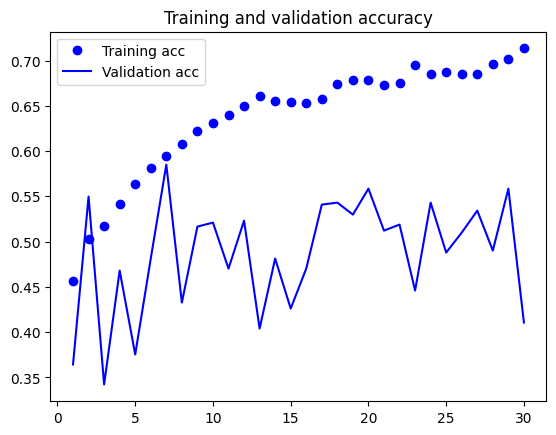
Best accuracy for NN was 0.618, however this may overfit. Manual selection of epoch resulted in 0.5475

Permutation importance identified top predictors for class “Dead.” - where year_of_birth, age_at_index (both suggestive of age being the most important factor) followed by not being hispanic ethnicity as well as gender influences.


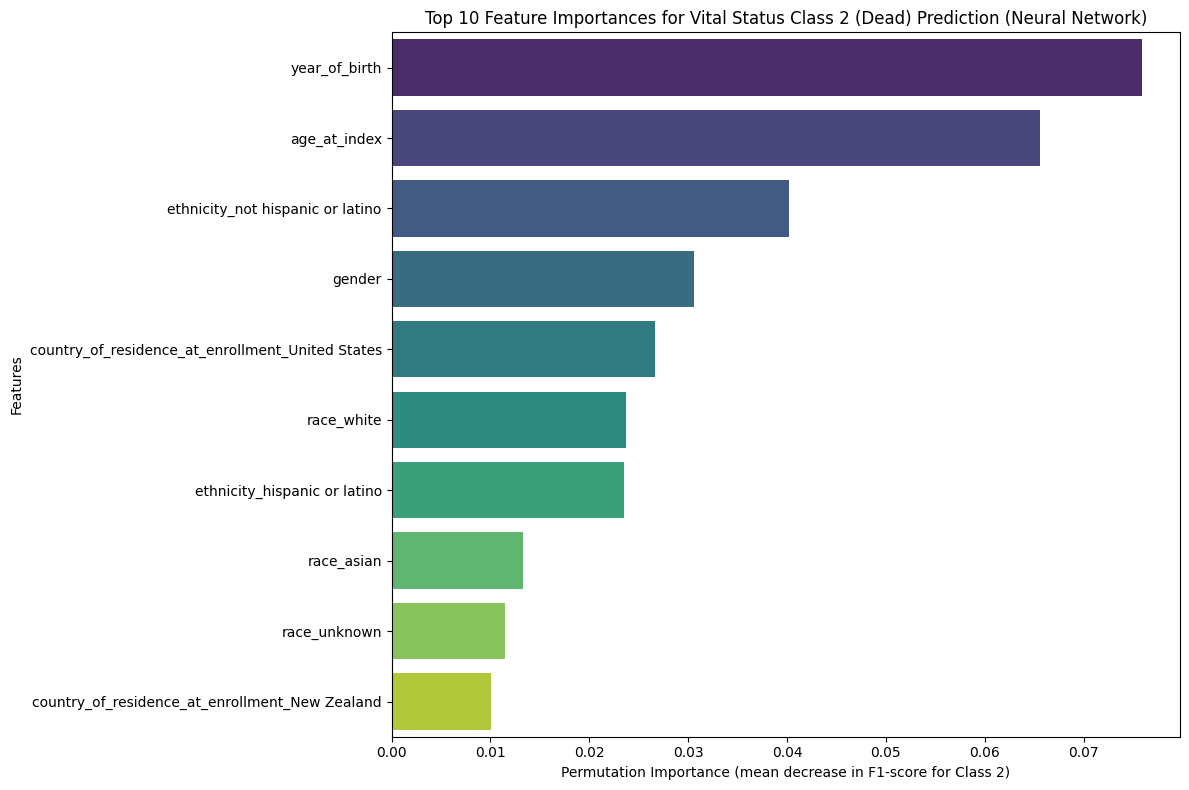
Additional results for Demographics vs. diagnostic typing, and Treatment type and 5-year survival will be incoming.